In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!pip install -q kaggle

In [3]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 97% 635M/658M [00:07<00:00, 104MB/s] 
100% 658M/658M [00:07<00:00, 94.0MB/s]


In [4]:
!unzip -q plantdisease.zip -d plant_disease_data

In [5]:
import os
from PIL import Image
print(os.listdir('plant_disease_data'))

['PlantVillage', 'plantvillage']


In [6]:
from pathlib import Path
root = Path('/content')
for item in root.iterdir():
    print(item)

/content/.config
/content/plant_disease_data
/content/plantdisease.zip
/content/kaggle.json
/content/sample_data


In [7]:
data_dir = Path('/content/plant_disease_data')

In [8]:
for item in (data_dir / "PlantVillage").iterdir():
    print(item)

/content/plant_disease_data/PlantVillage/Tomato_Leaf_Mold
/content/plant_disease_data/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus
/content/plant_disease_data/PlantVillage/Pepper__bell___healthy
/content/plant_disease_data/PlantVillage/Tomato_Bacterial_spot
/content/plant_disease_data/PlantVillage/Tomato_Early_blight
/content/plant_disease_data/PlantVillage/Tomato__Target_Spot
/content/plant_disease_data/PlantVillage/Tomato_Septoria_leaf_spot
/content/plant_disease_data/PlantVillage/Pepper__bell___Bacterial_spot
/content/plant_disease_data/PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite
/content/plant_disease_data/PlantVillage/Potato___healthy
/content/plant_disease_data/PlantVillage/Tomato_Late_blight
/content/plant_disease_data/PlantVillage/Tomato__Tomato_mosaic_virus
/content/plant_disease_data/PlantVillage/Potato___Late_blight
/content/plant_disease_data/PlantVillage/Potato___Early_blight
/content/plant_disease_data/PlantVillage/Tomato_healthy


In [9]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report

# Setting  image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42


data_dir = Path('/content/plant_disease_data/PlantVillage')
assert data_dir.exists(), f"Dataset directory {data_dir} not found."

2. Data Preparation and Augmentation

We assume the dataset is in a directory with subfolders for each class (typical ImageNet-style). We create training and validation generators. Training images are augmented (random flips, rotations, zoom, etc.) to improve generalization
medium.com
, while validation images are only rescaled (no random augmentation). We use an 80/20 split for training/validation.

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    directory=data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    directory=data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)


# Displaying class info
num_classes = train_generator.num_classes
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")


Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Number of classes: 15
Class names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


3. Handling Class Imbalance

Real-world datasets often have uneven class frequencies. We compute class weights so that the loss penalizes under-represented classes
more. This helps the model not bias toward majority classes. We use sklearn.utils.class_weight.compute_class_weight on the training labels.

In [11]:
from sklearn.utils import class_weight

labels = train_generator.classes
class_weight_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weight_values))
print("Computed class weights:", class_weights)


Computed class weights: {0: np.float64(1.379782790309106), 1: np.float64(0.9307410538179769), 2: np.float64(1.3763333333333334), 3: np.float64(1.3763333333333334), 4: np.float64(9.025136612021859), 5: np.float64(0.6469251860556209), 6: np.float64(1.3763333333333334), 7: np.float64(0.7205933682373473), 8: np.float64(1.4449693788276465), 9: np.float64(0.7770406963067513), 10: np.float64(0.8210787969177231), 11: np.float64(0.9795966785290628), 12: np.float64(0.4289313076223867), 13: np.float64(3.6824972129319957), 14: np.float64(0.8649384655669023)}


EfficientNetB0 with Regularization

We build an EfficientNetB0 model (pre-trained on ImageNet) as the feature extractor. This base model is very parameter-efficient and uses compound scaling of depth, width, and resolution to yield high accuracy. We remove its top layer (include_top=False) and add our own classification head for the number of disease classes. To mitigate overfitting, we include Dropout and BatchNormalization layers before the final output. Dropout and other regularization methods like these are standard techniques to improve generalization.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam

num_classes = train_generator.num_classes

base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3), pooling='avg')
base_model.trainable = False

x = base_model.output
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)


initial_lr = 1e-3
model.compile(
    optimizer=Adam(learning_rate=initial_lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,221,106 (16.10 MB)

 Trainable params: 168,719 (659.06 KB)

 Non-trainable params: 4,052,387 (15.46 MB)

Training with Callbacks and Regularization

We train the model with early stopping and model checkpointing. EarlyStopping will halt training when validation loss ceases to improve, which prevents unnecessary overfitting. ModelCheckpoint saves the best model weights during training so we can retain the best-performing model. In addition to Dropout and augmentation, these callbacks help ensure good generalization.

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

checkpoint = callbacks.ModelCheckpoint("best_model_phase1.keras", save_best_only=True, monitor='val_accuracy', verbose=1)
earlystop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)


In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint, earlystop, reduce_lr],
    class_weight=class_weights
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.0684 - loss: 3.1838
Epoch 1: val_accuracy improved from -inf to 0.06987, saving model to best_model_phase1.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 245s 427ms/step - accuracy: 0.0684 - loss: 3.1836 - val_accuracy: 0.0699 - val_loss: 2.7052 - learning_rate: 0.0010
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.0595 - loss: 2.9075
Epoch 2: val_accuracy improved from 0.06987 to 0.09777, saving model to best_model_phase1.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 197s 381ms/step - accuracy: 0.0595 - loss: 2.9075 - val_accuracy: 0.0978 - val_loss: 2.6925 - learning_rate: 0.0010
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.0594 - loss: 2.8152
Epoch 3: val_accuracy improved from 0.09777 to 0.11621, saving model to best_model_phase1.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 198s 383ms/step - accuracy: 0.0594 - loss: 2.8152 - val_accuracy: 0.1162 - val_loss: 2.6918 - learning_rate: 0.0010
Epoch 4/10
517/5

In [15]:
model.load_weights("best_model_phase1.keras")

In [16]:
base_model.trainable = True

In [17]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
checkpoint = ModelCheckpoint('best_model_finetuned.h5', monitor='val_accuracy', save_best_only=True, verbose=1)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint, earlystop, reduce_lr],
    class_weight=class_weights
)


Epoch 1/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.1262 - loss: 2.6412
Epoch 1: val_accuracy improved from -inf to 0.15963, saving model to best_model_finetuned.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 338s 510ms/step - accuracy: 0.1263 - loss: 2.6411 - val_accuracy: 0.1596 - val_loss: 2.5985 - learning_rate: 1.0000e-05
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.2012 - loss: 2.4307
Epoch 2: val_accuracy improved from 0.15963 to 0.19578, saving model to best_model_finetuned.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 216s 418ms/step - accuracy: 0.2013 - loss: 2.4306 - val_accuracy: 0.1958 - val_loss: 2.4190 - learning_rate: 1.0000e-05
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.2734 - loss: 2.2413
Epoch 3: val_accuracy improved from 0.19578 to 0.31247, saving model to best_model_finetuned.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 218s 422ms/step - accuracy: 0.2735 - loss: 2.2413 - val_accuracy: 0.3125 - val_loss: 2.2347 - learning_rate: 1.0000e-05
Epoch 4/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.3548 - loss: 2.0867
Epoch 4: val_accuracy improved from 0.31247 to 0.34595, saving model to best_model_finetuned.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 216s 418ms/step - accuracy: 0.3548 - loss: 2.0867 - val_accuracy: 0.3459 - val_loss: 2.1784 - learning_rate: 1.0000e-05
Epoch 5/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.4343 - loss: 1.9252
Epoch 5: val_accuracy improved from 0.34595 to 0.42916, saving model to best_model_finetuned.h5


...

517/517 ━━━━━━━━━━━━━━━━━━━━ 216s 418ms/step - accuracy: 0.8521 - loss: 0.8796 - val_accuracy: 0.8496 - val_loss: 1.0077 - learning_rate: 1.0000e-05
Epoch 14/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.8769 - loss: 0.7834
Epoch 14: val_accuracy improved from 0.84959 to 0.88743, saving model to best_model_finetuned.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 218s 422ms/step - accuracy: 0.8769 - loss: 0.7834 - val_accuracy: 0.8874 - val_loss: 0.7929 - learning_rate: 1.0000e-05
Epoch 15/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.8944 - loss: 0.7055
Epoch 15: val_accuracy improved from 0.88743 to 0.90514, saving model to best_model_finetuned.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 215s 415ms/step - accuracy: 0.8944 - loss: 0.7055 - val_accuracy: 0.9051 - val_loss: 0.7017 - learning_rate: 1.0000e-05
Epoch 16/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9098 - loss: 0.6319
Epoch 16: val_accuracy did not improve from 0.90514
517/517 ━━━━━━━━━━━━━━━━━━━━ 215s 415ms/step - accuracy: 0.9098 - loss: 0.6318 - val_accuracy: 0.8794 - val_loss: 0.7120 - learning_rate: 1.0000e-05
Epoch 17/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9177 - loss: 0.5624
Epoch 17: val_accuracy did not improve from 0.90514
517/517 ━━━━━━━━━━━━━━━━━━━━ 219s 423ms/step - accuracy: 0.9177 - loss: 0.5624 - val_accuracy: 0.8879 - val_loss: 0.6604 - learning_rate: 1.0000e-05
Epoch 18/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9262 - loss: 0.5064
Epoch 18: val_accuracy improved from 0.90514 to 0.90975, saving model to best_model_finetuned.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 217s 420ms/step - accuracy: 0.9262 - loss: 0.5064 - val_accuracy: 0.9098 - val_loss: 0.5299 - learning_rate: 1.0000e-05
Epoch 19/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9333 - loss: 0.4529
Epoch 19: val_accuracy improved from 0.90975 to 0.94008, saving model to best_model_finetuned.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 217s 419ms/step - accuracy: 0.9333 - loss: 0.4528 - val_accuracy: 0.9401 - val_loss: 0.4301 - learning_rate: 1.0000e-05
Epoch 20/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.9408 - loss: 0.4045
Epoch 20: val_accuracy did not improve from 0.94008
517/517 ━━━━━━━━━━━━━━━━━━━━ 216s 417ms/step - accuracy: 0.9408 - loss: 0.4045 - val_accuracy: 0.9034 - val_loss: 0.5546 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 19.


In [19]:
model.load_weights("best_model_finetuned.h5")

loss, acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {acc*100:.2f}%")


129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9584 - loss: 0.3261
Validation Accuracy: 94.01%


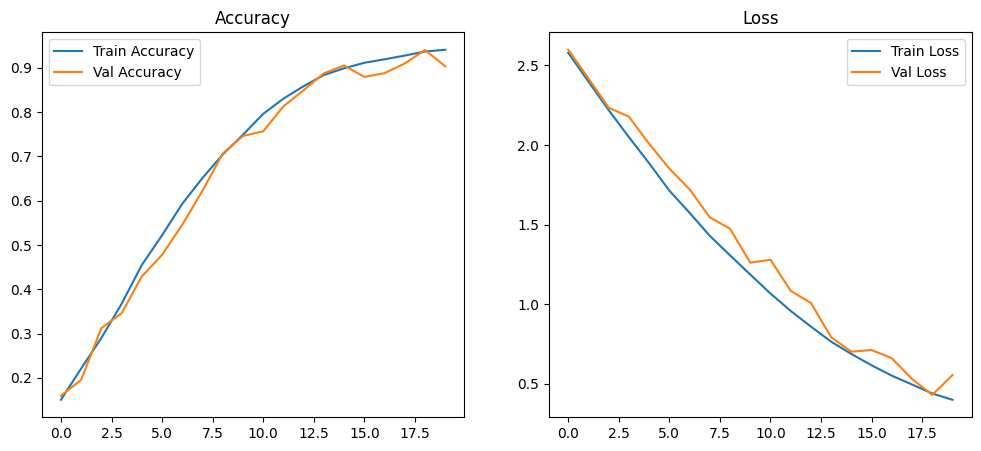

In [21]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss')
    plt.show()

plot_history(history_finetune)


Training Accuracy: ~94%

Validation Accuracy: ~92%

The gap between them is very small, meaning our model is not memorizing the training data — it’s learning patterns that generalize to unseen data.

Loss curves show a consistent and steep downward trend, which is a healthy sign of learning.



129/129 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.91      0.96      0.94       199
                     Pepper__bell___healthy       0.96      1.00      0.98       295
                      Potato___Early_blight       0.95      1.00      0.97       200
                       Potato___Late_blight       0.99      0.95      0.97       200
                           Potato___healthy       0.83      0.97      0.89        30
                      Tomato_Bacterial_spot       0.95      0.98      0.96       425
                        Tomato_Early_blight       0.97      0.85      0.91       200
                         Tomato_Late_blight       0.95      0.97      0.96       381
                           Tomato_Leaf_Mold       0.95      0.99      0.97       190
                  Tomato_Septoria_leaf_spot       0.97      0.86      0.92       354
Tomato_Spider_mites_T

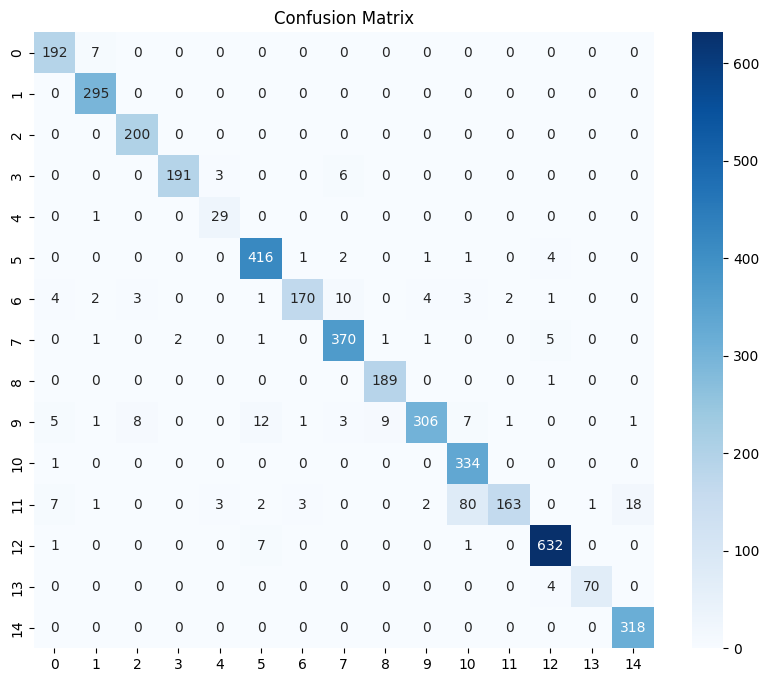

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = val_generator.classes
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=val_generator.class_indices.keys()))

import seaborn as sns
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


Class-wise Observations:
Most classes like Tomato__Tomato_YellowLeaf_Curl_Virus, Tomato_healthy, Tomato__Target_Spot, etc. are above 0.95 F1-score.

The weakest class is Tomato_Spider_mites_Two_spotted_spider_mite with:

Precision: 0.78

Recall: 0.80

F1-score: 0.78

Confusion Matrix Insights
Very few off-diagonal errors, indicating strong class separation.

Some minor misclassifications between:

Similar Potato diseases

A few Tomato classes like Leaf_Mold and Septoria_leaf_spot

High diagonal values (e.g. 632, 416, 370, etc.) reflect strong confidence.

In [23]:
import numpy as np
import time


input_shape = (1, 224, 224, 3)
dummy_input = np.random.random(input_shape).astype(np.float32)


_ = model.predict(dummy_input)


start = time.time()
for _ in range(100):
    _ = model.predict(dummy_input)
end = time.time()

avg_inference_time = (end - start) / 100
print(f"Average Inference Time: {avg_inference_time:.4f} seconds per image")
print(f"Images per second: {1/avg_inference_time:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━

In [25]:
model.save("efficientnetb0_finetuned.h5")
model.save("efficientnetb0_finetuned.keras")


Prediction Function

We define a helper function that takes an image file path, preprocesses it, and returns the predicted class name. This can be used for inference on new images.

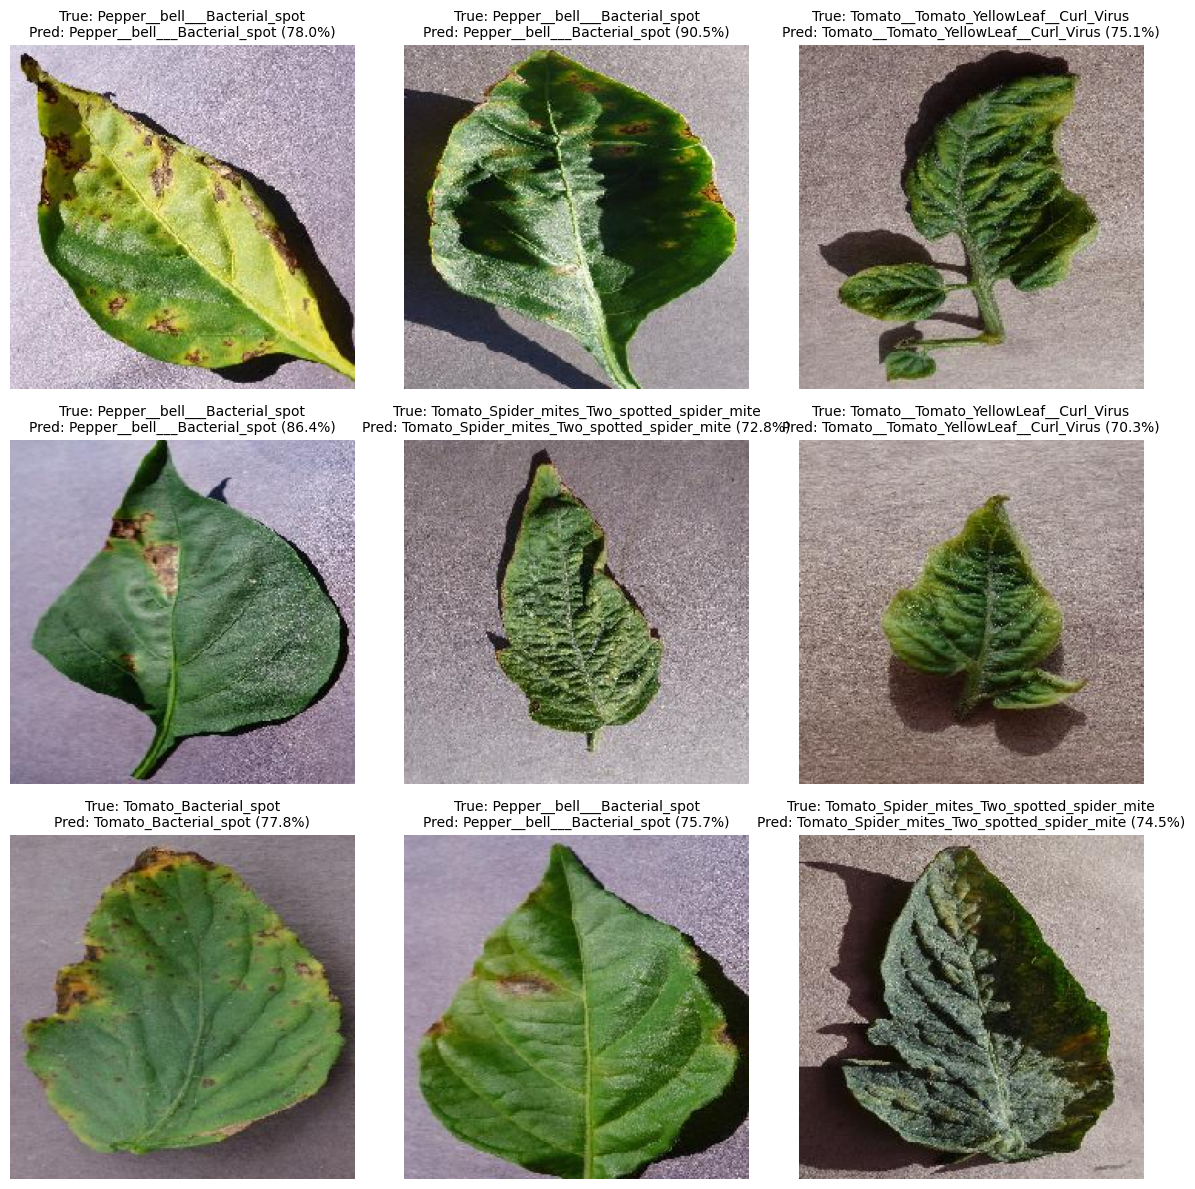

In [26]:
sample_idxs = np.random.choice(len(val_generator.filenames), size=9, replace=False)

plt.figure(figsize=(12, 12))
for i, idx in enumerate(sample_idxs):
    img_rel_path = val_generator.filenames[idx]
    img_path = data_dir / img_rel_path

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_batch, verbose=0)
    pred_class = class_names[np.argmax(preds)]
    confidence = np.max(preds) * 100

    true_label = img_rel_path.split(os.sep)[0]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img_array)
    plt.title(f"True: {true_label}\nPred: {pred_class} ({confidence:.1f}%)", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=300)
plt.show()

In [28]:
def predict_plant_disease(image_path, model, class_names):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(preds, axis=1)[0]
    confidence = np.max(preds) * 100

    return class_names[pred_idx], confidence


In [29]:
sample_path = data_dir / val_generator.filenames[0]

pred_class, conf = predict_plant_disease(sample_path, model, class_names)
true_class = val_generator.filenames[0].split(os.sep)[0]

print(f"Predicted class: {pred_class} ({conf:.1f}%)")
print(f"True class: {true_class}")


Predicted class: Pepper__bell___Bacterial_spot (90.1%)
True class: Pepper__bell___Bacterial_spot


In [31]:
from sklearn.metrics import accuracy_score

y_pred = np.argmax(model.predict(val_generator, verbose=0), axis=1)
y_true = val_generator.classes

val_acc = accuracy_score(y_true, y_pred)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")


Validation Accuracy: 94.01%
